In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as  sns
import numpy as np
from sklearn.metrics import mean_absolute_error




In [2]:
zillow_grouped_df = pd.read_csv('Resources/zillow_quarterly.csv')
zillow_grouped_df


,Unnamed: 0,RegionID,Neighborhood,City,Year,Quarter,Avg Annual Home Value
0,0,6018,Montbello,Denver,2000,1,127119.42
1,1,6018,Montbello,Denver,2000,2,131496.90
2,2,6018,Montbello,Denver,2000,3,137494.02
3,3,6018,Montbello,Denver,2000,4,142838.48
4,4,6018,Montbello,Denver,2001,1,148532.88
...,...,...,...,...,...,...,...
7671,7671,403518,Cole,Denver,2024,1,566195.31
7672,7672,403518,Cole,Denver,2024,2,566684.93
7673,7673,403518,Cole,Denver,2024,3,557518.96
7674,7674,403518,Cole,Denver,2024,4,551247.18


In [3]:
print(zillow_grouped_df['Avg Annual Home Value'].isna().sum())

182


In [4]:
df_model = zillow_grouped_df.copy()


In [5]:
df_model = df_model.dropna(subset=['Avg Annual Home Value']).reset_index(drop=True)

In [6]:
#  Define y 
y = df_model['Avg Annual Home Value']
#display sample of y
y[:5]

0    127119.42
1    131496.90
2    137494.02
3    142838.48
4    148532.88
Name: Avg Annual Home Value, dtype: float64

In [7]:
X = df_model.drop(['Avg Annual Home Value'], axis=1)
X[:5]

,Unnamed: 0,RegionID,Neighborhood,City,Year,Quarter
0,0,6018,Montbello,Denver,2000,1
1,1,6018,Montbello,Denver,2000,2
2,2,6018,Montbello,Denver,2000,3
3,3,6018,Montbello,Denver,2000,4
4,4,6018,Montbello,Denver,2001,1


In [8]:
# create dummy for categorical columns(Neighborhood and City)
X = pd.get_dummies(X, columns=['Neighborhood', 'City'], drop_first=True)

In [9]:
# Confirm no NaNs in Target
print("NaNs in target y:", y.isna().sum())  # Should be 0

NaNs in target y: 0


In [10]:
# Confirm no NaNs in Features
print("NaNs in features X:", X.isna().sum().sum())  # Should be 0

NaNs in features X: 0


In [11]:
#Split Into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
#score the model using the test data
print(f"Training Data Score: {model.score(X_train, y_train)}")
print(f"Testing Data Score: {model.score(X_test, y_test)}")

Training Data Score: 0.8651137331353216
Testing Data Score: 0.8659000441531335


In [15]:
#  Predict on the test set
y_pred = model.predict(X_test)

In [16]:
# Step 1: Calculate the Mean Squared Error (MSE) between actual values (y_test) and predicted values (y_pred)
# MSE measures how far off the predictions are from actual values on average (lower is better)
mean_squared_error_value = mean_squared_error(y_test, y_pred)
r_squared_error_value = r2_score(y_test, y_pred)
mpe = np.mean((y_test - y_pred) / y_test) * 100
mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # Convert to %
rmse = np.sqrt(mean_squared_error_value)





In [17]:
# Print all metrics
#print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error_value:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Percentage Error (MPE): {mpe:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r_squared_error_value:.4f}")

Mean Squared Error (MSE): 6,729,612,601.54
Root Mean Squared Error (RMSE): 82,034.22
Mean Percentage Error (MPE): 0.06%
Mean Absolute Percentage Error (MAPE): 22.61%
R-squared (R²): 0.8659


In [18]:
model_evaluation_results = pd.DataFrame({
    'Metric': ['Mean Squared Error (MSE)', 'R-squared Value', 'Mean Percentage Error (MPE)', 'Mean Absolute Percentage Error (MAPE)', 'Root Mean Squared Error (RMSE)'],
    'Value': [mean_squared_error_value, r_squared_error_value,mpe, mape, rmse]
    
})

In [19]:
# Display the DataFrame
model_evaluation_results

,Metric,Value
0,Mean Squared Error (MSE),6.729613e+09
1,R-squared Value,8.659000e-01
2,Mean Percentage Error (MPE),6.162064e-02
3,Mean Absolute Percentage Error (MAPE),2.261053e+01
4,Root Mean Squared Error (RMSE),8.203422e+04


In [20]:
# Predictions vs Actuals DataFrame
predictions_df = pd.DataFrame({
    "Predicted Home Value": y_pred,
    "Actual Home Value": y_test.reset_index(drop=True)
})

In [21]:
display(predictions_df.head(5))

,Predicted Home Value,Actual Home Value
0,192460.304075,193618.99
1,484778.800416,483014.33
2,403990.839023,427296.97
3,191754.208217,229580.21
4,311695.752623,224930.54


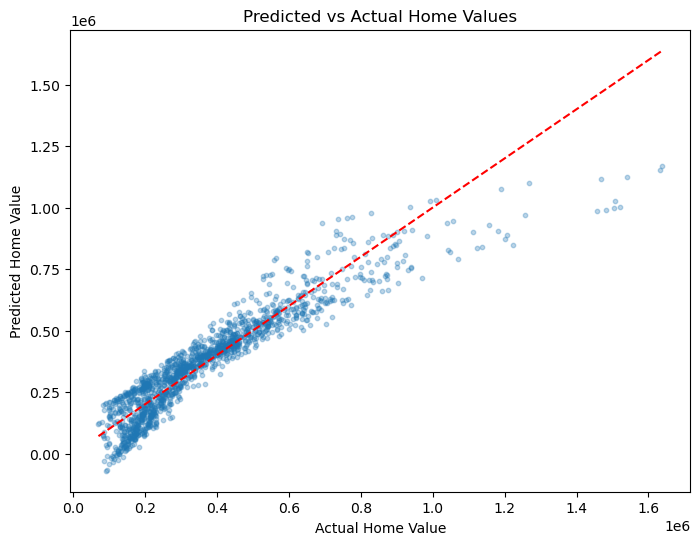

In [22]:
# --- Scatter Plot of Predictions vs Actuals ---
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.xlabel("Actual Home Value")
plt.ylabel("Predicted Home Value")
plt.title("Predicted vs Actual Home Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.show()


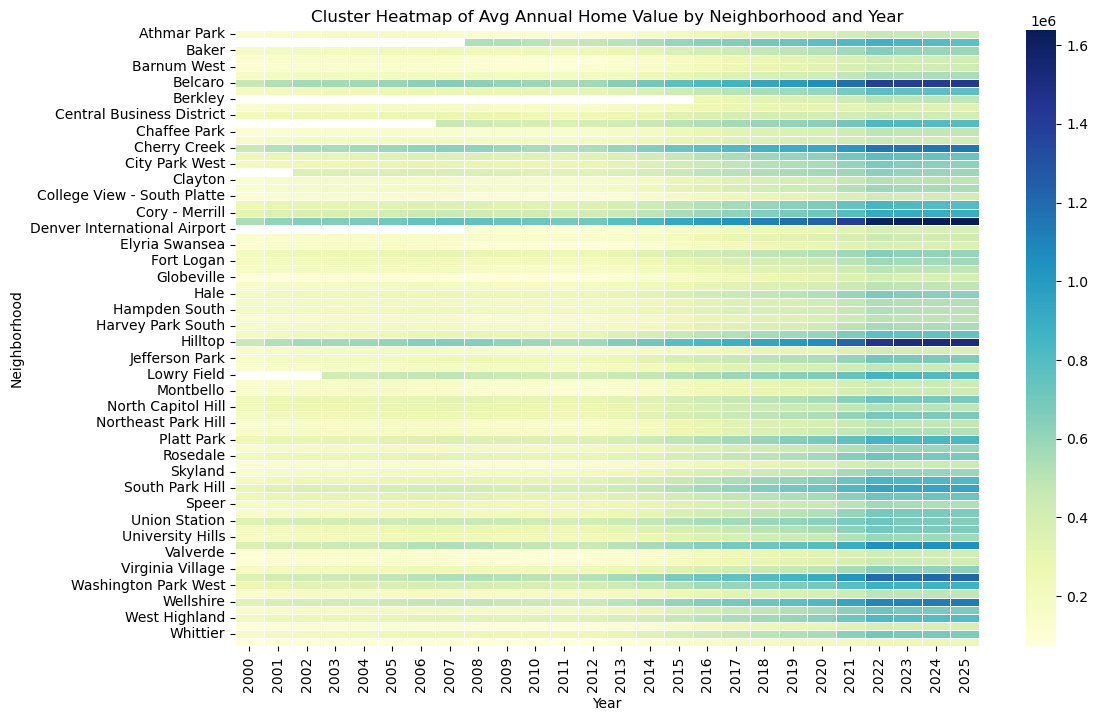

In [23]:
# --- Cluster Heatmap by Neighborhood (Optional) ---
# Prepare data for cluster map
# Use original grouped_quarterly_df if you want quarterly trends
import seaborn as sns
heatmap_data = df_model.pivot_table(index="Neighborhood", columns="Year", values="Avg Annual Home Value", aggfunc='mean')

# Plot cluster heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot= False, fmt=".0f", linewidths=0.5)
plt.title("Cluster Heatmap of Avg Annual Home Value by Neighborhood and Year")
plt.show()

In [24]:
# Step 1: Get top 10 neighborhoods by average value
top_neighborhoods = (
    df_model.groupby("Neighborhood")["Avg Annual Home Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)
top_neighborhoods

['Country Club',
 'Hilltop',
 'Belcaro',
 'Cherry Creek',
 'Washington Park',
 'Auraria',
 'University Park',
 'Wellshire',
 'Central Park',
 'Lowry Field']

In [25]:
# Find the 10 lowest-value neighborhoods by average annual home value
lowest_neighborhoods = (
    df_model.groupby("Neighborhood")["Avg Annual Home Value"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
    .index
    .tolist()
)
lowest_neighborhoods

['Windsor',
 'Globeville',
 'Westwood',
 'Elyria Swansea',
 'Valverde',
 'Barnum',
 'Villa Park',
 'Barnum West',
 'College View - South Platte',
 'Montbello']

In [26]:
# Combine both lists (avoid duplicates)
selected_neighborhoods = top_neighborhoods + lowest_neighborhoods


In [27]:
# Step 2: Select recent years
selected_years = list(range(2015, 2025))

In [28]:
# Step 3: Filter data
heatmap_filtered = heatmap_data.loc[selected_neighborhoods, selected_years]

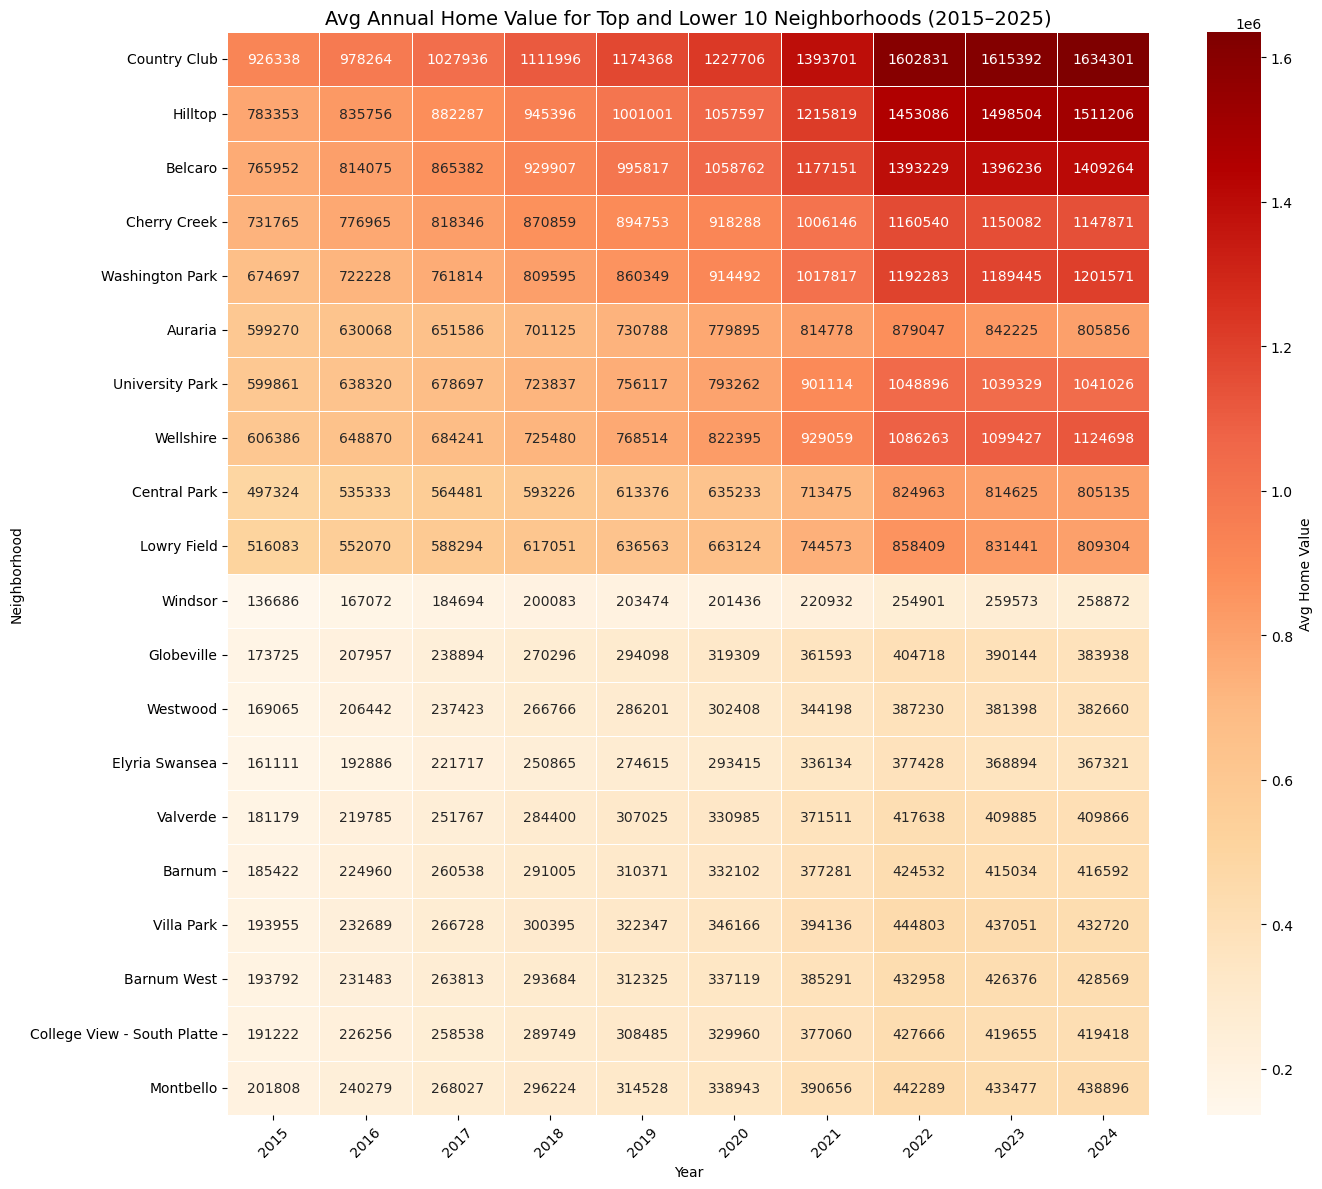

In [29]:
# Step 4: Plot heatmap
plt.figure(figsize=(14, 12))  # Adjust size for clarity
sns.heatmap(
    heatmap_filtered,
    cmap="OrRd",                # Red-Orange color map
    annot=True,                 # Show values in cells
    fmt=".0f",                  # Whole numbers only
    linewidths=0.5,             # Thin grid lines
    cbar_kws={'label': 'Avg Home Value'}
)
plt.title("Avg Annual Home Value for Top and Lower 10 Neighborhoods (2015–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Neighborhood")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [30]:
# Clean column names
df_model.columns = df_model.columns.str.strip()
# Drop rows with missing values in essential columns
future_df = df_model.dropna(subset=["Neighborhood", "Year", "Avg Annual Home Value"])


# Prepare storage for predictions
forecasts = []

In [31]:
# Define future years for prediction
future_years = list(range(2024, 2036))

In [32]:
 #Loop through each neighborhood and fit a linear regression model
for neighborhood, group in future_df.groupby("Neighborhood"):
    # Prepare data
    X = group["Year"].values.reshape(-1, 1)
    y = group["Avg Annual Home Value"].values

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Predict for future years
    y_pred = model.predict(np.array(future_years).reshape(-1, 1))
    
    # Store predictions
    for year, value in zip(future_years, y_pred):
        forecasts.append({
            "Neighborhood": neighborhood,
            "Year": year,
            "Predicted Home Value": round(value, 2)
        })

# Create DataFrame with predictions
forecast_df = pd.DataFrame(forecasts)

In [33]:
forecast_df.head(10)

,Neighborhood,Year,Predicted Home Value
0,Athmar Park,2024,398356.42
1,Athmar Park,2025,411850.02
2,Athmar Park,2026,425343.62
3,Athmar Park,2027,438837.22
4,Athmar Park,2028,452330.82
5,Athmar Park,2029,465824.42
6,Athmar Park,2030,479318.02
7,Athmar Park,2031,492811.62
8,Athmar Park,2032,506305.22
9,Athmar Park,2033,519798.82


In [34]:
forecast_df.to_csv('Resources/regression_forecast.csv', index=False)

PermissionError: [Errno 13] Permission denied: 'Resources/regression_forecast.csv'

In [35]:
# Filter for 2035
forecast_2035 = forecast_df[forecast_df['Year'] == 2035]

In [36]:
# Top 10 neighborhoods by predicted value
top10 = forecast_2035.sort_values(by='Predicted Home Value', ascending=False).head(10)


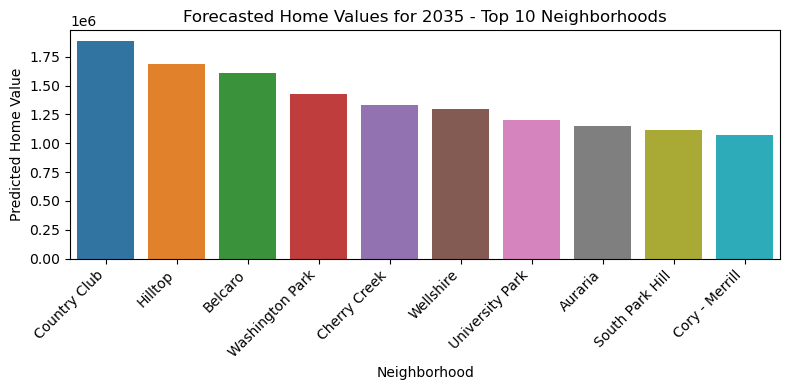

In [37]:
# Plot bar chart
plt.figure(figsize=(8, 4))
sns.barplot(data=top10, x='Neighborhood', y='Predicted Home Value', hue='Neighborhood')
plt.xticks(rotation=45, ha='right')
plt.title('Forecasted Home Values for 2035 - Top 10 Neighborhoods')
plt.tight_layout()
plt.show()

In [38]:
# Bottom 10 neighborhoods by predicted value
bottom10 = forecast_2035.sort_values(by='Predicted Home Value').head(10)

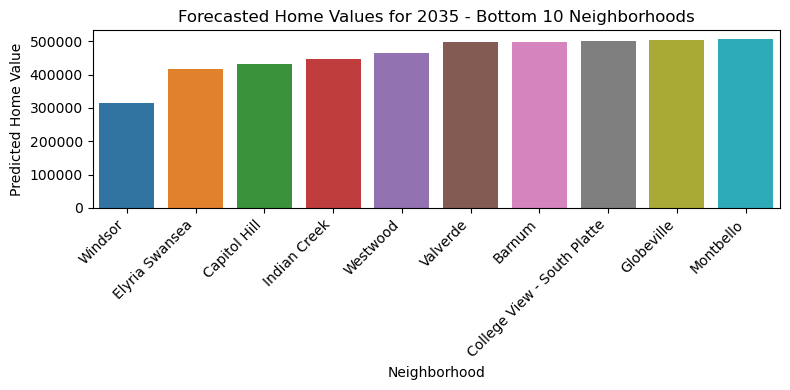

In [39]:
# Plot bar chart
plt.figure(figsize=(8, 4))
sns.barplot(data=bottom10, x='Neighborhood', y='Predicted Home Value', hue='Neighborhood')
plt.xticks(rotation=45, ha='right')
plt.title('Forecasted Home Values for 2035 - Bottom 10 Neighborhoods')
plt.tight_layout()
plt.show()

In [40]:
# Combined top 10 and bottom 10
combined = pd.concat([top10, bottom10])

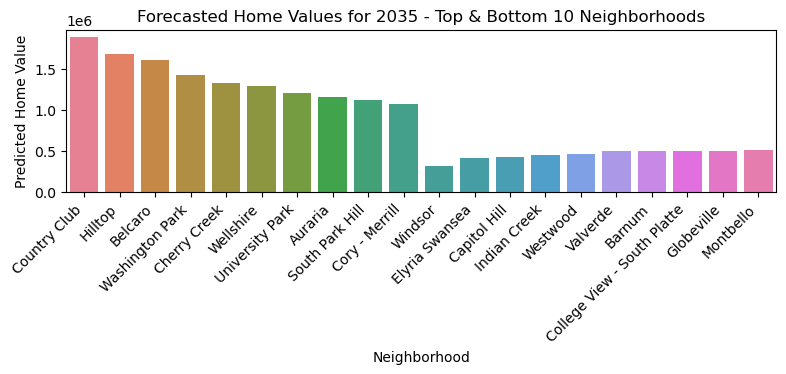

In [41]:
# Plot bar chart
plt.figure(figsize=(8, 4))
sns.barplot(data=combined, x='Neighborhood', y='Predicted Home Value', hue='Neighborhood')
plt.xticks(rotation=45, ha='right')
plt.title('Forecasted Home Values for 2035 - Top & Bottom 10 Neighborhoods')
plt.tight_layout()
plt.show()

In [42]:
# --- Line Plot for Trends Over Time (2024–2035) ---
# Select top 5 and bottom 5 neighborhoods to simplify the line plot
simple_top5 = top10.head(5)['Neighborhood'].tolist()
simple_bottom5 = bottom10.head(5)['Neighborhood'].tolist()
simple_selected = simple_top5 + simple_bottom5


In [43]:
# Filter forecast data for selected neighborhoods
line_data = forecast_df[forecast_df['Neighborhood'].isin(simple_selected)]


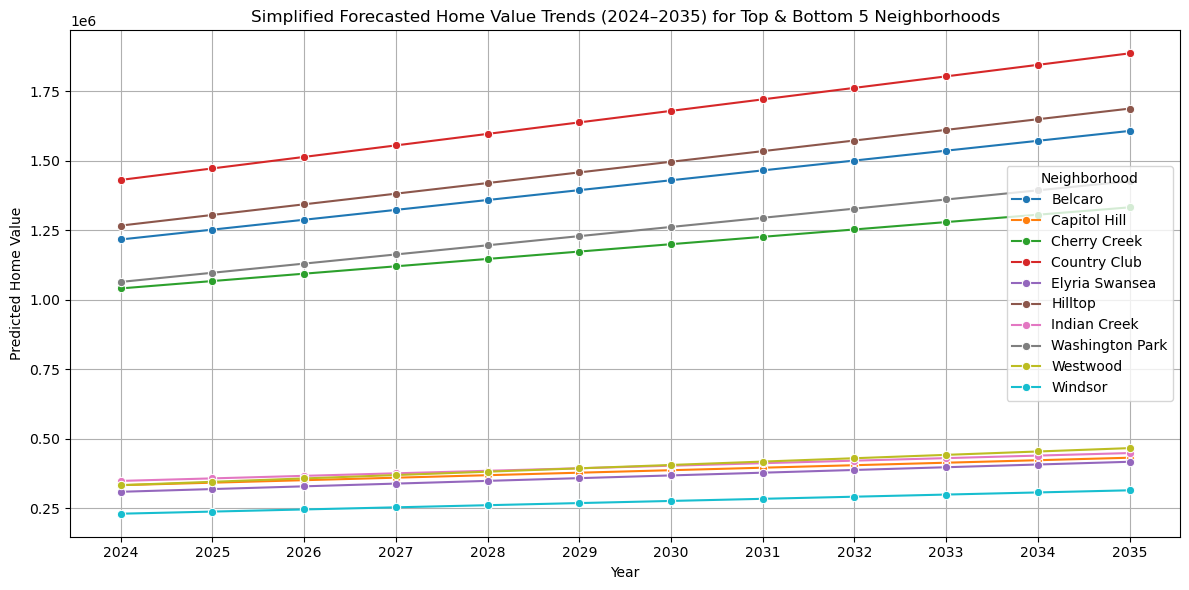

In [44]:

# Plot simplified line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=line_data, x='Year', y='Predicted Home Value', hue='Neighborhood', marker='o')
plt.title('Simplified Forecasted Home Value Trends (2024–2035) for Top & Bottom 5 Neighborhoods')
plt.xticks(future_years)
plt.ylabel('Predicted Home Value')
plt.grid(True)
plt.tight_layout()
plt.show()



In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [46]:
# Build the model
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100


c:\Users\rober\anaconda3\envs\dev\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 188881469440.0000 - mae: 375434.7812 - val_loss: 180576157696.0000 - val_mae: 362053.5938
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 189886988288.0000 - mae: 371888.5312 - val_loss: 166516424704.0000 - val_mae: 343975.4688
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 164479942656.0000 - mae: 341986.0938 - val_loss: 134862159872.0000 - val_mae: 299776.5312
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 128460218368.0000 - mae: 291139.2500 - val_loss: 92492193792.0000 - val_mae: 229515.4688
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 84412571648.0000 - mae: 216559.0625 - val_loss: 54583455744.0000 - val_mae: 154033.1562
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 48363937792.0000 - mae: 146604.8125 - val_loss: 32482301952.0000 - val_mae: 117778.3359
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 29276805120.0000 - mae: 112560.7344 - val_loss: 23

In [47]:
# Predict
y_pred = model.predict(X_test_scaled).flatten()

# Evaluate with scikit-learn

#MSE
mse = mean_squared_error(y_test, y_pred)

#RMSE
rmse = np.sqrt(mse)

#R2
r2 = r2_score(y_test, y_pred)

# MPE
mpe = np.mean((y_test - y_pred) / y_test) * 100

# Evaluate with Keras
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

# Print all metrics
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Percentage Error (MPE): {mpe:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Mean Absolute Error (MAE): 24,647.71
Mean Squared Error (MSE): 1,645,337,290.95
Root Mean Squared Error (RMSE): 40,562.76
Mean Percentage Error (MPE): -0.92%
R-squared (R²): 0.9672
